# CC-WBT-AI — Input Pipeline

Workflow: set inputs → write to files → run engine → read outputs

In [27]:
import sys, os, openpyxl as _xl
 
_cwd = os.path.abspath('')
if os.path.exists(os.path.join(_cwd, 'backend')):
    ROOT = _cwd
elif os.path.exists(os.path.join(_cwd, '..', 'backend')):
    ROOT = os.path.dirname(_cwd)
else:
    raise FileNotFoundError("Cannot find the backend folder")
 
BACKEND   = os.path.join(ROOT, 'backend')
NOTEBOOKS = os.path.join(ROOT, 'notebooks')
sys.path.insert(0, BACKEND)
sys.path.insert(0, NOTEBOOKS)

from pipeline_helpers import PipelineIO
print('Setup OK')

Setup OK


## 1. Model and technologies

In [28]:
COUNTRY    = 'Mozambique'
MODEL      = 'CleanStep'
TECHS      = ['Electricity', 'LPG']
START_YEAR = 2023
END_YEAR   = 2034
YEARS      = list(range(START_YEAR, END_YEAR + 1))
 
pio = PipelineIO(backend=BACKEND, country=COUNTRY, model=MODEL, techs=TECHS, start_year=START_YEAR, end_year=END_YEAR)
pio.ensure_model_exists()

Model CleanStep exists with the correct technologies.


## 2. Country-level inputs

In [29]:
# config
TAX_RATE  = 28
INFLATION = 5
 
# fuel financial inputs
FUEL_FIN = {
    'Electricity': {
        'NTL':      [5]*12,
        'DAYS_REC': [30]*12,
        'DAYS_PAY': [30]*12,
    },
    'LPG': {
        'NTL':      [5]*12,
        'DAYS_REC': [30]*12,
        'DAYS_PAY': [30]*12,
    },
}
 
# carbon credits (fuel-financial-inputs)
CC_CO2_CERT  = [0]*12
CC_LIQUIDITY = [0]*12
CC_PRICE_TON = [0]*12
CC_NUM_YEARS = 0
 
print('Country-level inputs defined.')

Country-level inputs defined.


## 3. Model-level inputs

In [30]:
# capital structure (design-financial-structure)
CAPITAL_STRUCTURE = {
    'Electricity & E-Cooking': {
        'PCT_EQUITY':        20,
        'COST_OF_EQUITY':    16,
        'PCT_GRANTS':        50,
        'YEARS_REALISATION': 8,
        'COST_OF_DEBT':      8,
        'GRACE_PERIOD':      6,
        'AMORTIZATION':      25,
        'DEBT_INCREASE':     [100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    },
    'Electricity (Low access)': {
        'PCT_EQUITY':        25,
        'COST_OF_EQUITY':    12,
        'PCT_GRANTS':        55,
        'YEARS_REALISATION': 8,
        'COST_OF_DEBT':      8,
        'GRACE_PERIOD':      6,
        'AMORTIZATION':      25,
        'DEBT_INCREASE':     [0]*12,
    },
    'LPG': {
        'PCT_EQUITY':        50,
        'COST_OF_EQUITY':    12,
        'PCT_GRANTS':        20,
        'YEARS_REALISATION': 2,
        'COST_OF_DEBT':      8,
        'GRACE_PERIOD':      6,
        'AMORTIZATION':      25,
        'DEBT_INCREASE':     [0]*12,
    },
}
 
# technoeconomic-inputs - Electricity (GRID/OFF-GRID)
TECHNO_ELEC = {
    'Electricity & E-Cooking': {
        'GRID': {
            'Demand':             [1473.6, 1616.8, 1793.2, 1954.5, 3101.6, 2235.1, 2355.9, 2518.5, 1659.5, 2786.4, 2900, 3001],
            'CAPEX - Growth':     [257.3,  324.6,  321.4,  318.2, 315, 311.8, 382, 451.1, 446.6, 442.1, 437.7, 290.8],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [48.2,   54.6,   62.2,   69.6, 77, 84.1, 91.1, 102.2, 112.7, 123, 133.1, 143],
            'D&A':                35,
        },
        'OFF-GRID': {
            'Demand':             [368.4, 379.3, 393.6, 400.3, 400.3, 394.4, 383.5, 376.3, 362.7, 344.4, 322.2, 296.8],
            'CAPEX - Growth':     [39.5,  50.3, 49.8, 49.3, 48.8, 48.4, 15.4, -17.1, -16.9, -16.8, -16.6, -1.7],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [56.1,  64.7, 74.9, 84.8, 94.5, 104, 113.4, 111.6, 105.1, 98.8, 92.6, 86.4],
            'D&A':                25,
        },
    },
    'Electricity (Low access)': {
        'GRID': {
            'Demand':              [1442.6, 1496.4, 1584.4, 1666.1, 1741.6, 1811.1, 1874.7, 1933.7, 1991.3, 2044.1, 2092.2, 2135.7],
            'CAPEX - Growth':      [214.8,   248.1,   245.6,   243.1,   240.7,   238.3,   276.1,   313.4,   310.3,   307.2,   304.1,   208.6],
            'CAPEX - Maintenance': [0]*12,
            'OPEX':                [46.2,    47.9,    50.9,    53.8,    56.7,    59.5,    62.2,    71,    81.3,    91.4,    101.3,   111  ],
            'D&A': 35,
        },
        'OFF-GRID': {
            'Demand':             [368.4,  379.3,  393.6,  400.3,  400.3,  394.4,  383.5,  376.3,  362.7,  344.4,  322.2,  296.8],
            'CAPEX - Growth':     [39.5,   50.3,   49.8,   49.3,   48.8,   48.4,   15.4,   -17.1,  -16.9,  -16.8,  -16.6,  -1.7],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [56.1,   64.7,   74.9,   84.8,   94.5,   104.0,  113.4,  111.6,  105.1,  98.8,   92.6,   86.5],
            'D&A': 25,
        },
    },
}
 
# technoeconomic-inputs — LPG (other fuels)
TECHNO_LPG = {
    'Demand':             [301.9,  326.6,  438.7,  539.3,  629.3,  709.6,  780.8,  970.5,  949.4,  928.2,  906.8,  885.4],
    'CAPEX - Growth':     [2.7,    4.8,    4.8,    4.7,    4.7,    4.7,    3.7,    2.6,    2.6,    2.6,    2.6,    2.5],
    'CAPEX - Maintenance':[0]*12,
    'OPEX':               [25.5,   36.4,   51.4,   66.3,   81.2,   96.0,   110.8,  115.4,  118.1,  120.7,  123.4,  126.0],
    'D&A': 15,
}
 
# tariffs & upstreams
TARIFFS = {
    'Electricity': [0.15, 0.16, 0.17, 0.17, 0.18, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24, 0.26],
    'LPG':         [0.08, 0.08, 0.08, 0.09, 0.09, 0.10, 0.10, 0.11, 0.11, 0.12, 0.12, 0.13],
}
UPSTREAMS = {
    'Electricity': [0]*12,
    'LPG':         [0]*12,
}
 
# CO2 emitted (carbon-credits)
CO2_BASELINE = [21.61, 20.602, 19.838, 19.074, 18.311, 17.547, 16.783, 16.436, 16.367, 16.298, 16.229, 16.160]
CO2_EMITTED = [21.611, 19.405, 17.428, 15.452, 13.475, 11.498, 9.521, 9.105, 9.190, 9.275, 9.360, 9.446]
 
print('Model-level inputs defined.')

Model-level inputs defined.


## 4. Write inputs

In [31]:
print('=== COUNTRY-LEVEL ===')
pio.write_config_scalar('TAX_RATES',  TAX_RATE)
pio.write_config_scalar('INFLATIONS', INFLATION)
 
for fuel, vals in FUEL_FIN.items():
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Expected non-technical losses',        vals['NTL'])
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Trade receivables - Days of revenues', vals['DAYS_REC'])
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Trade payables - Days of OPEX costs',  vals['DAYS_PAY'])
 
pio.write_timeseries_list      (pio.fuel_fin_path, 'Carbon Credits', 'CO2 certificate (%) - from the total CO2 avoided', CC_CO2_CERT)
pio.write_timeseries_list      (pio.fuel_fin_path, 'Carbon Credits', 'Liquidity',     CC_LIQUIDITY)
pio.write_timeseries_list      (pio.fuel_fin_path, 'Carbon Credits', 'Price per TON', CC_PRICE_TON)
pio.write_timeseries_first_year(pio.fuel_fin_path, 'Carbon Credits', 'Number of years that you could sell those carbon credits', CC_NUM_YEARS)
 
print('=== MODEL-LEVEL ===')
for sheet, cs in CAPITAL_STRUCTURE.items():
    pio.write_excel_scalar(pio.design_cap_path, sheet, '1. Equity',           cs['PCT_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Equity',      cs['COST_OF_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, '2. Grants',           cs['PCT_GRANTS'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Years realisation',   cs['YEARS_REALISATION'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Debt',        cs['COST_OF_DEBT'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Grace period',        cs['GRACE_PERIOD'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Amortization period', cs['AMORTIZATION'])
    pio.write_design_debt_list(sheet, cs['DEBT_INCREASE'])
 
for sheet, systems in TECHNO_ELEC.items():
    for system, params in systems.items():
        for param, values in params.items():
            if param == 'D&A': pio.write_techno_da(sheet, system, values)
            else:               pio.write_techno_list(sheet, system, param, values)
 
for param, values in TECHNO_LPG.items():
    if param == 'D&A': pio.write_techno_nosystem_da('LPG', values)
    else:               pio.write_techno_nosystem_list('LPG', param, values)
 
for tech, vals in TARIFFS.items():
    pio.write_config_timeseries('TARIFFS',   tech, YEARS, vals)
for tech, vals in UPSTREAMS.items():
    pio.write_config_timeseries('UPSTREAMS', tech, YEARS, vals)
 
pio.write_carbon_row('CO2 emited - Baseline scenario', CO2_BASELINE)
pio.write_carbon_co2_emitted(CO2_EMITTED, YEARS)
print('\nAll inputs written.')

=== COUNTRY-LEVEL ===
  config.json -> TAX_RATES = 28
  config.json -> INFLATIONS = 5
  fuel-financial-inputs.xlsx / Electricity -> Expected non-technical losses
  fuel-financial-inputs.xlsx / Electricity -> Trade receivables - Days of revenues
  fuel-financial-inputs.xlsx / Electricity -> Trade payables - Days of OPEX costs
  fuel-financial-inputs.xlsx / LPG -> Expected non-technical losses
  fuel-financial-inputs.xlsx / LPG -> Trade receivables - Days of revenues
  fuel-financial-inputs.xlsx / LPG -> Trade payables - Days of OPEX costs
  fuel-financial-inputs.xlsx / Carbon Credits -> CO2 certificate (%) - from the total CO2 avoided
  fuel-financial-inputs.xlsx / Carbon Credits -> Liquidity
  fuel-financial-inputs.xlsx / Carbon Credits -> Price per TON
  fuel-financial-inputs.xlsx / Carbon Credits -> Number of years that you could sell those carbon credits (first year)
=== MODEL-LEVEL ===
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 1. Equity = 20
  design-capital-Clea

## 5. Run engine

In [32]:
print('Running engine...')
df_conv = pio.run_engine_until_convergence(max_iter=30, tol=1e-2)
print('Done.')

Running engine...
  Converged in 14 iterations.
Done.


In [33]:
df_conv

,iteration,DC::Electricity & E-Cooking::How much to be financed,DC::Electricity & E-Cooking::Equity,DC::Electricity & E-Cooking::Grants,DC::Electricity & E-Cooking::Debt,DC::Electricity & E-Cooking::WACC,DC::Electricity (Low access)::How much to be financed,DC::Electricity (Low access)::Equity,DC::Electricity (Low access)::Grants,DC::Electricity (Low access)::Debt,...,FS::Electricity & E-Cooking::Cash Flow from Assets,FS::LPG::Long term subsidies,FS::LPG::Annual Cost of Service,FS::LPG::Operating Cash Flow,FS::LPG::Cash Flow from Assets,FS::Electricity (Low access)::Long term subsidies,FS::Electricity (Low access)::Annual Cost of Service,FS::Electricity (Low access)::Operating Cash Flow,FS::Electricity (Low access)::Cash Flow from Assets,max_delta
0,1,922.613911,184.522782,461.306955,100.0,13.188274,764.972461,191.243115,420.734854,0.0,...,-261.036110,-296.892969,-1195.601153,49.011726,6.011726,-106.633653,-939.384705,3099.776463,-282.923537,NaN
1,2,922.612793,184.522559,461.306396,100.0,13.188272,765.109995,191.277499,420.810497,0.0,...,-261.035210,-296.667173,-1195.599061,47.192533,4.192533,-106.659813,-939.377929,3100.453034,-282.246966,1.819193e+00
2,3,922.612455,184.522491,461.306227,100.0,13.188271,764.821228,191.205307,420.651676,0.0,...,-261.035682,-296.485267,-1195.599061,46.923733,3.923733,-106.690032,-939.363951,3100.694749,-282.005251,2.887667e-01
3,4,922.612632,184.522526,461.306316,100.0,13.188272,764.811011,191.202753,420.646056,0.0,...,-261.035825,-296.332104,-1195.599061,46.674933,3.674933,-106.700522,-939.358857,3100.933446,-281.766554,2.488000e-01
4,5,922.612686,184.522537,461.306343,100.0,13.188272,764.836383,191.209096,420.660011,0.0,...,-261.035750,-296.203661,-1195.599061,46.449333,3.449333,-106.705292,-939.356132,3101.048646,-281.651354,2.256000e-01
5,6,922.612658,184.522532,461.306329,100.0,13.188272,764.886508,191.221627,420.687580,0.0,...,-261.035728,-296.097546,-1195.599061,46.250133,3.250133,-106.708165,-939.352567,3101.119617,-281.580383,1.992000e-01
6,7,922.612649,184.522530,461.306325,100.0,13.188272,764.986486,191.246621,420.742567,0.0,...,-261.035739,-296.006641,-1195.599061,46.080533,3.080533,-106.703722,-939.351290,3101.156852,-281.543148,1.696000e-01
7,8,922.612654,184.522531,461.306327,100.0,13.188272,765.018097,191.254524,420.759953,0.0,...,-261.035743,-295.927604,-1195.599061,45.931733,2.931733,-106.691606,-939.348875,3101.135457,-281.564543,1.488000e-01
8,9,922.612655,184.522531,461.306327,100.0,13.188272,765.099011,191.274753,420.804456,0.0,...,-261.035741,-295.865245,-1195.599061,45.806133,2.806133,-106.684621,-939.348875,3101.029172,-281.670828,1.256000e-01
9,10,922.612654,184.522531,461.306327,100.0,13.188272,765.099011,191.274753,420.804456,0.0,...,-261.035741,-295.820433,-1195.599061,45.706133,2.706133,-106.672467,-939.348875,3100.979046,-281.720954,1.000000e-01


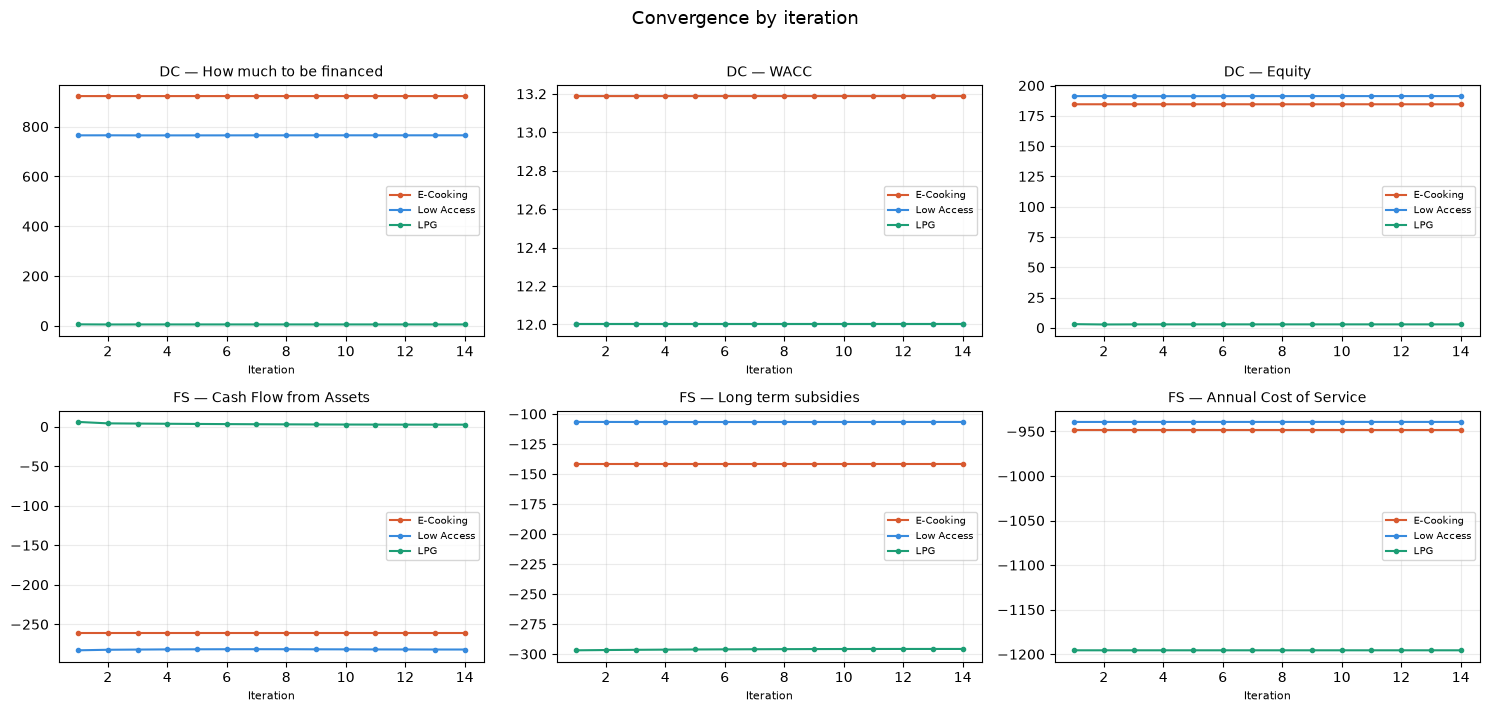

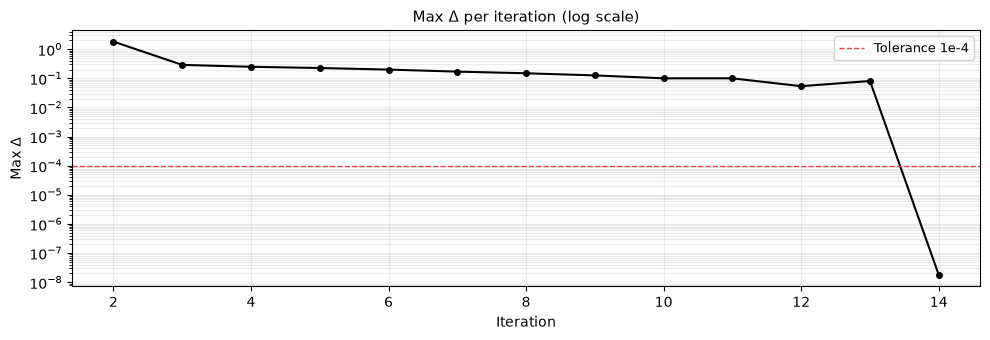

In [34]:
pio.plot_convergence(df_conv)

## 6. Outputs

In [35]:
for SHEET in pio.get_expanded_sheets():
    out = pio.read_outputs(SHEET)
    if not out:
        continue
    print(f"\n{'='*70}")
    print(f"  {SHEET}")
    print('='*70)
    header = f"{'Row':<35}" + ''.join(f"{y:>{col_w}}" for y in YEARS)
    print(header)
    print('-' * len(header))
    for key, values in out.items():
        print(f"{key:<35}" + ''.join(f"{round(v,1):>{col_w}}" for v in values))


  Electricity & E-Cooking
Row                                      2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Long term subsidies                         0         0         0      -6.3         0     -10.3     -14.1     -14.9     -39.7     -21.2     -19.7     -16.0
Operating Cash Flow                     103.4     138.2     163.8     214.9     307.4     316.6     370.6     428.4     484.0     537.3     588.3     617.2
Financial Expense                          -4        -8        -8        -8        -8        -8      -7.8      -7.5      -7.2      -6.9      -6.6      -6.2
Debt repayment                              0         0         0         0         0         0        -4        -4        -4        -4        -4        -4
Equity - EoP                         

## 7. Summary metrics

In [36]:
lts      = out.get('Long term subsidies',  [0]*len(YEARS))
equity   = out.get('Equity - EoP',         [0]*len(YEARS))
debt_eop = out.get('DEBT:EoP',             [0]*len(YEARS))
grants   = out.get('GRANTS:- Realisation', [0]*len(YEARS))

_wb = _xl.load_workbook(pio.design_cap_path, data_only=True)
_ws = _wb[SHEET]
wacc = next(
    (row[2].value for row in _ws.iter_rows(max_col=3) if row[0].value == 'WACC'),
    None
)
_wb.close()

total_lts    = round(sum(lts), 1)
total_grants = round(sum(abs(v) for v in grants), 1)
peak_equity  = round(max(equity), 1)
peak_debt    = round(max(abs(v) for v in debt_eop), 1)

print(f"WACC:               {wacc:.2f}%")
print(f"Total LTS:          {total_lts} M$")
print(f"Total grants:       {total_grants} M$")
print(f"Peak equity (EoP):  {peak_equity} M$")
print(f"Peak debt (EoP):    {peak_debt} M$")

WACC:               12.00%
Total LTS:          -295.8 M$
Total grants:       1.5 M$
Peak equity (EoP):  23.2 M$
Peak debt (EoP):    0 M$


In [37]:
_grid   = TECHNO_ELEC.get('Electricity & E-Cooking', {}).get('GRID', {})
_demand = _grid.get('Demand', [])
_capex  = _grid.get('CAPEX - Growth', [])
_opex   = _grid.get('OPEX', [])
 
K1 = [round(_capex[i] / _demand[i], 4) if _demand[i] else 0 for i in range(len(YEARS))]
K2 = [round(_capex[i] / _opex[i],   4) if _opex[i]   else 0 for i in range(len(YEARS))]
print(f"K1 (CAPEX/Demand): {K1}")
print(f"K2 (CAPEX/OPEX):   {K2}")

K1 (CAPEX/Demand): [0.1746, 0.2008, 0.1792, 0.1628, 0.1016, 0.1395, 0.1621, 0.1791, 0.2691, 0.1587, 0.1509, 0.0969]
K2 (CAPEX/OPEX):   [5.3382, 5.9451, 5.1672, 4.5718, 4.0909, 3.7075, 4.1932, 4.4139, 3.9627, 3.5943, 3.2885, 2.0336]
